# S3 · Градиентный спуск своими руками

Шесть последовательных блоков. Четыре сообщения придуманы для занятия. Формулы совпадают с L1. `x` — число слов free, win, prize; `y` — метка спама. Начало каждого запуска — первая ячейка.

Основной маршрут: 65 минут. Данные и импорты подготовлены. В начальной версии вычислительные ячейки дописываются по ходу разбора. В полной версии сохранены выполненный код и результаты.

### Подготовлено: импорты

In [1]:
from math import exp, log

import matplotlib.pyplot as plt


## 1. Сообщение и один признак

`lower` меняет регистр, `split` выделяет слова, `strip` убирает знаки с краёв. `append` добавляет одно значение в конец списка. Ожидаем x=[0,1,2,3].

In [2]:
messages = [
    "See you at six",
    "Are you free tomorrow",
    "Win a free ticket",
    "Free prize win now",
]
y = [0, 0, 1, 1]


def count_words(message):
    count = 0
    for word in message.lower().split():
        word = word.strip(".,!?;:")
        if word in ["free", "win", "prize"]:
            count = count + 1
    return count


x = []
for message in messages:
    x.append(count_words(message))
print("x =", x)
print("y =", y)


x = [0, 1, 2, 3]
y = [0, 0, 1, 1]


## 2. Прогноз при известных параметрах

`def` описывает функцию, её вызов вычисляет результат. `return` возвращает число. До обучения все p=0.5.

In [3]:
def probability(x_value, w, b):
    z = w * x_value + b
    return 1 / (1 + exp(-z))


w = 0.0
b = 0.0
for i in range(len(x)):
    p = probability(x[i], w, b)
    print("x =", x[i], "y =", y[i], "p =", round(p, 3))


x = 0 y = 0 p = 0.5
x = 1 y = 0 p = 0.5
x = 2 y = 1 p = 0.5
x = 3 y = 1 p = 0.5


## 3. Средняя потеря

`total` накапливает сумму. `log` — натуральный логарифм. Возврат среднего находится после цикла. Ожидаем 0.693147.

In [4]:
def mean_loss(x, y, w, b):
    total = 0.0
    for i in range(len(x)):
        p = probability(x[i], w, b)
        loss = -y[i] * log(p) - (1 - y[i]) * log(1 - p)
        total = total + loss
    return total / len(x)


print("Потеря до обучения:", round(mean_loss(x, y, w, b), 6))


Потеря до обучения: 0.693147


## 4. Один шаг обучения

`dw` и `db` накапливают производные. Обе вычисляются при старых w,b. Ожидаем dw=-0.5, db=0; после шага w=0.5, b=0, L=0.545475.

In [5]:
def gradients(x, y, w, b):
    dw = 0.0
    db = 0.0
    for i in range(len(x)):
        p = probability(x[i], w, b)
        error = p - y[i]
        dw = dw + error * x[i]
        db = db + error
    return dw / len(x), db / len(x)


dw, db = gradients(x, y, w, b)
learning_rate = 1.0
w = w - learning_rate * dw
b = b - learning_rate * db
print("Градиент:", dw, db)
print("После шага:", w, b)
print("Потеря после шага:", round(mean_loss(x, y, w, b), 6))


Градиент: -0.5 0.0
После шага: 0.5 0.0
Потеря после шага: 0.545475


## 5. Повторение одного и того же шага

Параметры сбрасываются перед полным опытом. Нулевой элемент истории — потеря до обучения. Далее сохранено 200 новых значений, всего 201.

In [6]:
w = 0.0
b = 0.0
loss_history = [mean_loss(x, y, w, b)]
for step in range(200):
    dw, db = gradients(x, y, w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    loss_history.append(mean_loss(x, y, w, b))

print("После 200 шагов:", round(w, 3), round(b, 3))
print("Потеря:", round(loss_history[-1], 6))
for i in range(len(x)):
    print("x =", x[i], "p =", round(probability(x[i], w, b), 3))


После 200 шагов: 4.417 -6.357
Потеря: 0.054416
x = 0 p = 0.002
x = 1 p = 0.126
x = 2 p = 0.923
x = 3 p = 0.999


### Подготовлено: график вычисленной истории

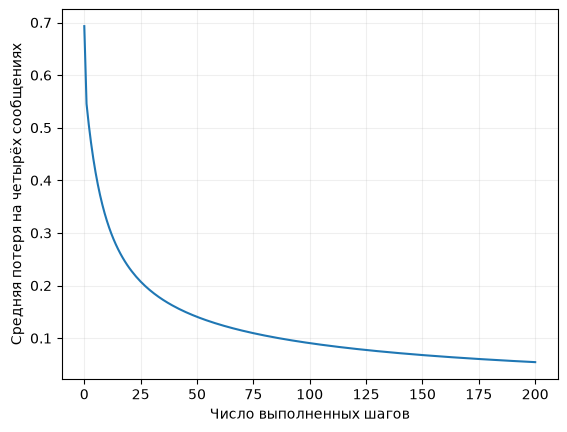

In [7]:
plt.plot(loss_history)
plt.xlabel("Число выполненных шагов")
plt.ylabel("Средняя потеря на четырёх сообщениях")
plt.grid(alpha=0.2)
plt.show()


## 6. Новое сообщение

Новая метка при прогнозе не нужна. Один счётчик не сохраняет контекст. Функции с exp/log здесь рассчитаны на небольшие значения учебного опыта. Для произвольных больших чисел применяют устойчивые библиотечные реализации.

In [8]:
new_message = "You win a prize today"
new_x = count_words(new_message)
new_p = probability(new_x, w, b)
print("Число слов:", new_x, "Оценка спама:", round(new_p, 3))

ordinary_message = "Are you free to win a prize at our family quiz"
ordinary_x = count_words(ordinary_message)
ordinary_p = probability(ordinary_x, w, b)
print("Семейная викторина:", ordinary_x, round(ordinary_p, 3))


Число слов: 2 Оценка спама: 0.923
Семейная викторина: 3 0.999
